# Using SimPy and simpy_helpers

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2023, University of Chicago 

---

This notebook will act as an introduction and tutorial to the Python `SimPy` package and its use with the additional helper package `simpy_helpers`.

The packages together give great flexibility to easily model systems as discrete event simulations.

Every simulation is built with 4 main classes.

- Entity
- Resource
- Source
- Stats

### Entity

An Entity is conceptually the "thing passing through your simulation", such as a customer, job, car, etc ...   

- An Entity requests Resources like a server, performs actions that take time, might jump out of long queues, etc...

- Each Entity has a set of attributes, stored internally as a dictionary. Examples of attributes might include:
    - Age
    - Food Preference
    - Last time they ate 
    - Number of items in their shopping cart
    - etc...
    
    
- `priority` attribute is always defined with a default value of 1.
   - The priority governs the sequence with which Entities are serviced by a Resource. 
   - The default value of 1 can be changed to another Integer value.  A smaller priority numbered entity will be serviced before an entity with a larger priority value.


- Entities track statistics about their journey through the simulation, including waiting and processing time.

You must define a `process` method for your Entity class.


### Resource

A Resource is something an Entity requests for service, and can wait for when necessary.

- Resources have a `capacity` which defines how many entities can enter and receive service from simultaneously, before a queue forms.
- Resources may access an entity's attributes to determine the type and length of service for that entity.
- Resources track statistics about their queues size and the nunber in service and their utilization over time. 

You must define a `service_time` method for your Resource class.

You can think of Entities as moving from one Resource to another throughout its life in a simulation.

### Source

A Source is used to start a simulation. It is responsible for the following:

- Defining a template for how entities are constructed and fed into a simulation.
- Defining the interarrival time, the time between entities entering the simulation.
- The interarrival time can be fixed or a random draw from a distribution.

You must define `interarrival_time` and `build_entity` methods for your Source class.

### Stats

The stats class collects summary statistics about your simulation. You can query it after your simulation completes to check out details of the simulation (e.g. total time per entity through the system, resource utilization over time, waiting time of entities at each resource, etc...)


#### SimPy tidbits

- Use `env.now` to return the current simulation clock time
- Use `server.count` to return the number of Entities currently in process at the Resource object `server` 
- Use `self.count` in a Source or Entity Class block to return the number of the Entity.  Counting begins at 0 

## An Example.  The M/M/1 Queueing System

The M/M/1 system is a basic single queue/single server system.
Arrivals request service from the single server, and if busy, queue in a single first-come-first-serve manner.  Interarrival times and service times are randomly drawn from an Exponential distribution.


In [1]:
# Install simpy and simpy_helpers the first time used on a local installation 
# by uncommenting the following line and executing the cell
# !pip install simpy
# !pip install simpy_helpers

In [2]:
import numpy as np
import simpy
from simpy_helpers import Entity, Resource, Source, Stats

In [3]:
# Specify the number of entities in the simulation
NUM_JOBS = 100

# Set the mean interarrival time and service time
MEAN_TIME_BETWEEN_ARRIVALS = 200 #seconds
MEAN_SERVICE_DURATION = 190

**Recall $M/M/1$ queueing theory from BUSN40000 Operations Management**

$$
\text{Inventory} = \frac{\rho^2}{1 - \rho}
$$

### Define the server Resource subclass

Each Resource subclass must define the method `service_time` which will return the service time of the resource.

In [4]:
class MyServer(Resource):
    
    def service_time(self, entity):
        return np.random.exponential(MEAN_SERVICE_DURATION)

### Define the Entity subclass

The Entity Subclass defines how an entity navigates through the simulation from one Resource to another.   

Each Entity subclass requires a `process` method that details its path through the simulation.

In [5]:
class MyJob(Entity):
    
    def process(self):
        
        # Wait (yield) until a Resource is available
        yield self.wait_for_resource(myserver) # myserver is an instance of MyServer

        # Wait (yield) while being processed by the resource
        yield self.process_at_resource(myserver)

        # Release the Resource
        self.release_resource(myserver)

        # Exit the simulation
        self.attributes['exit_time'] = env.now
        print(f'Entity {self.attributes['count']} at time {self.attributes['exit_time']} is exiting')

### Define the Source subclass

The Source subclass specifies when Entities are generated to join the simulation and what attributes they have.

There can be only one Source subclass and it must specify an `interarrival_time` method and a `build_entity` method.

In [6]:
class MyJobGenerator(Source):
    
    def interarrival_time(self):
        return np.random.exponential(MEAN_TIME_BETWEEN_ARRIVALS)

    def build_entity(self):
        attributes = {}
        attributes['count'] = self.count
        
        attributes['exit_time'] = None
        
        
        attributes['shopper'] = np.random.choice(['regular', 'VIP'])
        if attributes['shopper']=='VIP':
            attributes['priority'] = 1
        else:
            attributes['priority'] = 2
        
        return MyJob(env, attributes)

### Running the simulation

In [23]:
np.random.seed(429)
env = simpy.Environment()

myserver = MyServer(env, capacity=1)
mysource = MyJobGenerator(env, number=NUM_JOBS)

env.process(mysource.start(debug=False))

env.run()

Entity 1 at time 349.03212121340835 is exiting
Entity 2 at time 1117.8065738526484 is exiting
Entity 3 at time 1220.7892866858401 is exiting
Entity 4 at time 1234.7276356274842 is exiting
Entity 5 at time 1736.7043822259695 is exiting
Entity 6 at time 1740.4657526780927 is exiting
Entity 7 at time 1910.289712735659 is exiting
Entity 8 at time 2165.5678894237817 is exiting
Entity 9 at time 2230.216753381251 is exiting
Entity 10 at time 2253.8959576423154 is exiting
Entity 11 at time 2537.845054972649 is exiting
Entity 12 at time 2889.666371826421 is exiting
Entity 14 at time 2925.6470785203605 is exiting
Entity 15 at time 3012.861378002701 is exiting
Entity 16 at time 3013.1739516259977 is exiting
Entity 17 at time 3072.77805824919 is exiting
Entity 13 at time 3111.4276110560527 is exiting
Entity 18 at time 3745.0289445635563 is exiting
Entity 19 at time 3761.7979053653944 is exiting
Entity 20 at time 4089.6740419643324 is exiting
Entity 21 at time 4186.790925445006 is exiting
Entity 22

## The Stats subclass 

## Entity Statistics

The following methods are available for querying for summary statistics after a simulation has been run.  These produce a list with values for each Entity that has completed the simulation.


`Stats.get_total_times(attributes=None)` - returns a list of the total time each entity spent in the system
- attributes:  optional dictionary of attributes to filter on

`Stats.get_waiting_times(resource=None, attributes=None)` - returns either the total waiting times or waiting time at a particular resource for each entity.
- attributes:  optional dictionary of attributes to filter on
- resource: optional resource to filter on 

`Stats.get_processing_times(resource=None, attributes=None)` - returns either the total processing time or processing time at a particular resource for each entity.
- attributes:  optional dictionary of attributes to filter on
- resource: optional resource to filter on 


In [8]:
len(Stats.get_total_times())

100

In [9]:
print(f'Average time in the system is {np.mean(Stats.get_total_times())}')

Average time in the system is 1196.6023438823645


In [10]:
print(f'Average waiting time in the system is {np.mean(Stats.get_waiting_times())}')

Average waiting time in the system is 1002.7136796076552


In [11]:
print(f'Average processing time in the system is {np.mean(Stats.get_processing_times())}')

Average processing time in the system is 193.88866427470907


In [12]:
print(f'Average processing time in the system for a particular resource is {np.mean(Stats.get_processing_times(myserver))}')

Average processing time in the system for a particular resource is 193.88866427470907


## Resource Statistics over time

These summary statistics produce a list of values over time on the activity at a Resource.  

`Stats.queue_size_over_time(resource, sample_frequency=[0.01, 0.1, 1])`  - returns a list of the queue size for a resource over the course of the simulation
- resource: the resource object name
- sample_frequency (optional) (default=1)

`Stats.utilization_over_time(resource, sample_frequency=[0.01, 0.1, 1])` - returns a list of the utilization of a resource over the course of simulation
- resource: the resource object name
- sample_frequency (optional) (default=1)

`Stats.number_being_processed_over_time(resource, sample_frequency=[0.01, 0.1, 1])` - returns a list of how many entities were being processed by this resource over the course of the simulation
- resource: the resource object name
- sample_frequency (optional) (default=1)


In [13]:
print(f'Average server queue size over time: {np.mean(Stats.queue_size_over_time(myserver))}')

Average server queue size over time: 4.42784597721452


In [14]:
print(f'Average server utilization over time: {np.mean(Stats.utilization_over_time(myserver))}')

Average server utilization over time: 0.8561776914245341


In [15]:
print(f'Average server number processed over time: {np.mean(Stats.number_being_processed_over_time(myserver))}')

Average server number processed over time: 0.8561776914245341


## Making plots

Matplotlib is a standard for producing plots.  Here is a nice
[Matplotlib Tutorial](https://matplotlib.org/stable/tutorials/introductory/pyplot.html)

In [16]:
import matplotlib.pyplot as plt

### Histograms

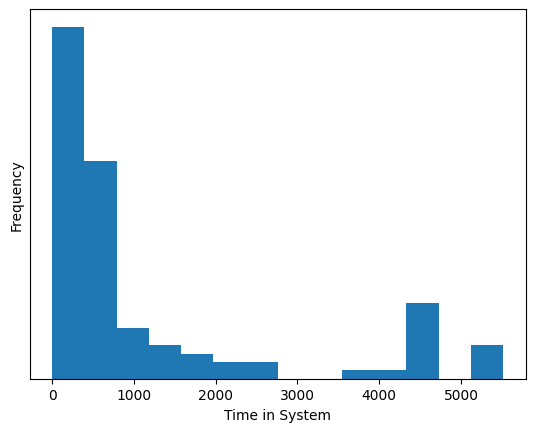

In [17]:
"""
Histogram of Total time in system
"""
system_time = Stats.get_total_times()
plt.hist(system_time,bins=14)
# you can customize the exact tick marks on an axis
# Turn off y tick numbrers 
plt.yticks([])
plt.ylabel('Frequency');
plt.xlabel('Time in System');
plt.show()

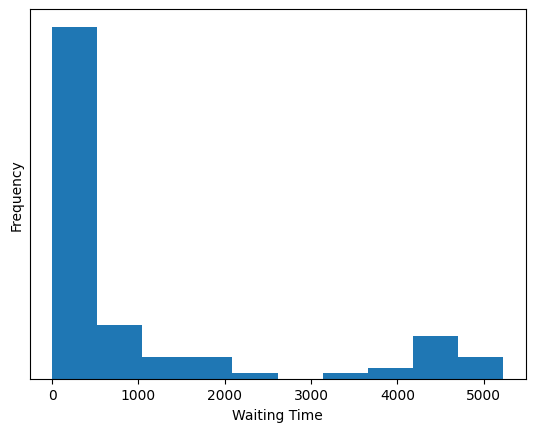

In [18]:
"""
Histogram of waiting time in system 
"""
wait_time = Stats.get_waiting_times()
plt.hist(wait_time)
plt.yticks(range(0,3))
plt.ylabel('Frequency');
plt.xlabel('Waiting Time');
# Turn off y tick numbrers 
plt.yticks([])
plt.show()

### Line plots

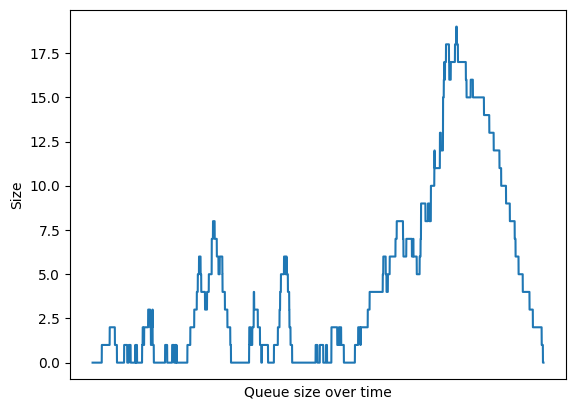

In [19]:
server_queue = Stats.queue_size_over_time(myserver)
plt.plot(server_queue)
plt.ylabel('Size');
plt.xlabel('Queue size over time');
# Turn off x tick numbrers 
plt.xticks([])
plt.show()

## Advanced: Entity Object level statistics



For more detailed analysis you may want to loop and filter entities (on their attributes for example) and gather your own statistics manually.

To get a list of all Entity objects you use:

`Stats.get_entities()` - returns a list of all Entity objects that have left the simulation.  

In [25]:
Stats.get_entities()

### You can call the following methods on an Entity Object:

`get_total_time()` - returns the total time that this entity spent in the system (from creation to exit).

`get_total_waiting_time()` - returns the total amount of time that the entity waited across *all* resources. 

`get_waiting_time_for_resource(resource)` - returns the amount of time that the entity waited at the given resource

`get_total_processing_time()` - returns the total amount of time spent processing at all resources during simulation. 

`get_processing_time_for_resource(resource)` - returns the processing time of the entity at the given resource

In [26]:
first_entity = Stats.get_entities()[1]

In [27]:
first_entity.get_total_time()

683.0880621929066

### Challenge 1

- Divide up entities randomly and equally distributed into Regular and VIP customers.   
- VIP customers queue ahead of Regular customers.   
- Print out the average waiting time of each group 

In [21]:
print('Average wait time for Regular:', np.mean(Stats.get_waiting_times(myserver, attributes={'shopper': 'regular'})))

Average wait time for Regular: 1610.5800179675618


In [22]:
print('Average wait time for VIP:', np.mean(Stats.get_waiting_times(myserver, attributes={'shopper': 'VIP'})))

Average wait time for VIP: 289.13145631559115


### Challenge 2

- How many customers take longer than are processed by simulation time 6000?

In [29]:
exit_count = 0

for entity in Stats.get_entities():
    if entity.attributes['exit_time'] > 6000:
        exit_count += 1
print(exit_count)

74


### Challenge 3
- What percent of customers take longer than 250 time units at the resource?

In [32]:
long_queueing_time_count = 0

for entity in Stats.get_entities():
    if entity.get_waiting_time_for_resource(myserver) > 250:
        long_queueing_time_count += 1
print(long_queueing_time_count)

57
